<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Histogram**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab, you will perform the following:


- Visualize the distribution of data using histograms.

- Visualize relationships between features.

- Explore data composition and comparisons.


## Demo: Working with database


#### Download the database file.


In [64]:
!wget -O survey-data.sqlite https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

--2026-04-14 06:45:37--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-data.sqlite’

survey-data.sqlite  100%[===================>] 201.62M  47.8MB/s    in 4.2s    

2026-04-14 06:45:42 (47.8 MB/s) - ‘survey-data.sqlite’ saved [211415040/211415040]



#### Install the required libraries and import them


In [65]:
!pip install pandas

In [66]:
!pip install matplotlib

In [67]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

#### Connect to the SQLite database


In [68]:
conn = sqlite3.connect('survey-data.sqlite')

## Demo: Basic SQL queries

**Demo 1: Count the number of rows in the table**


In [69]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437


**Demo 2: List all tables**


In [43]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


**Demo 3: Group data by age**


In [44]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


## Hands-on Lab: Visualizing Data with Histograms


### 1. Visualizing the distribution of data (Histograms)


**1.1 Histogram of `CompTotal` (Total Compensation)**


Objective: Plot a histogram of `CompTotal` to visualize the distribution of respondents' total compensation.


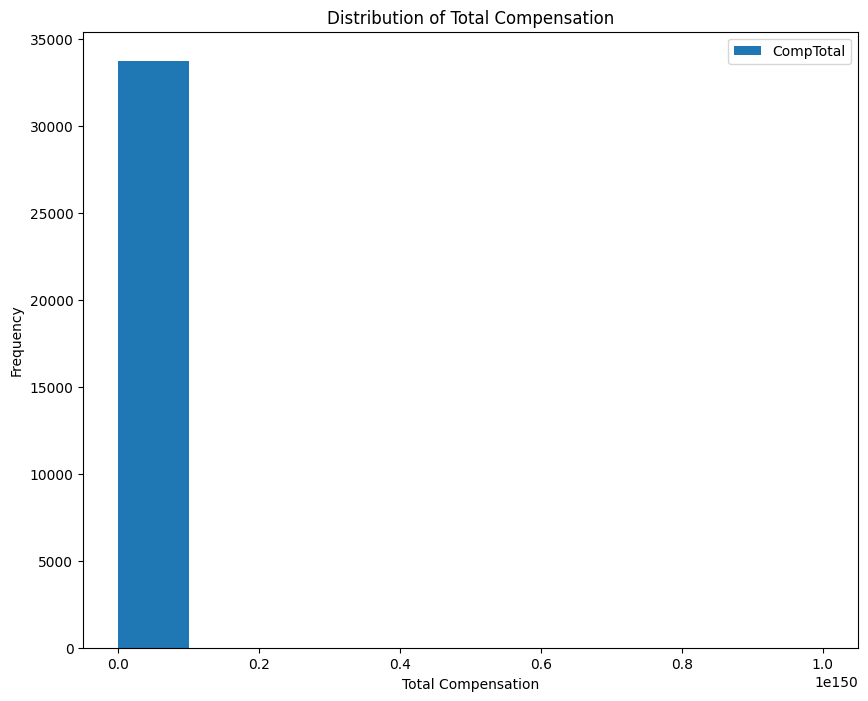

In [10]:
## Write your code 
QUERY1 = """
SELECT CompTotal FROM main"""

df_comptotal = pd.read_sql_query(QUERY1, conn)
df_comptotal = df_comptotal.dropna()
df_comptotal.plot(kind='hist', bins=10, figsize=(10, 8))

plt.title('Distribution of Total Compensation')
plt.xlabel('Total Compensation')
plt.ylabel('Frequency')

plt.show()

**1.2 Histogram of YearsCodePro (Years of Professional Coding Experience)**


Objective: Plot a histogram of `YearsCodePro` to analyze the distribution of coding experience among respondents.


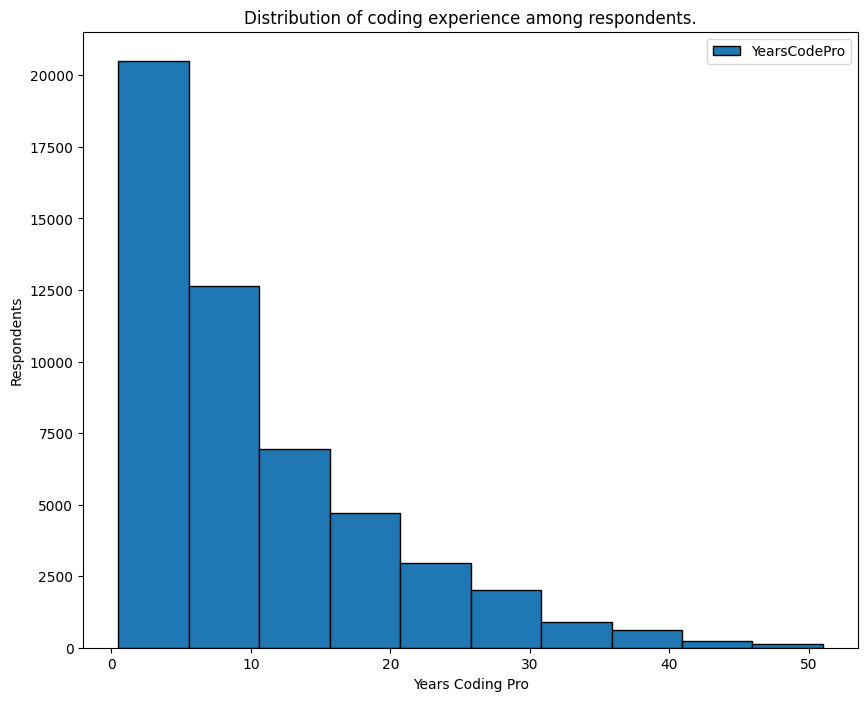

In [11]:
## Write your code here
QUERY2 = """
SELECT YearsCodePro FROM main"""
df_yearscodepro = pd.read_sql_query(QUERY2, conn)

df_yearscodepro['YearsCodePro'] = df_yearscodepro['YearsCodePro'].replace({
    'Less than 1 year': 0.5, 
    'More than 50 years': 51
})

df_yearscodepro = df_yearscodepro.dropna()
df_yearscodepro['YearsCodePro'] = pd.to_numeric(df_yearscodepro['YearsCodePro'], errors='coerce')
df_yearscodepro.plot(kind='hist', bins=10, figsize=(10, 8), edgecolor='black')

plt.title('Distribution of coding experience among respondents.')
plt.xlabel('Years Coding Pro')
plt.ylabel('Respondents')

plt.show()

### 2. Visualizing Relationships in Data


**2.1 Histogram Comparison of `CompTotal` by `Age` Group**


Objective: Use histograms to compare the distribution of CompTotal across different Age groups.


Note: you may need to restart the kernel to use updated packages.


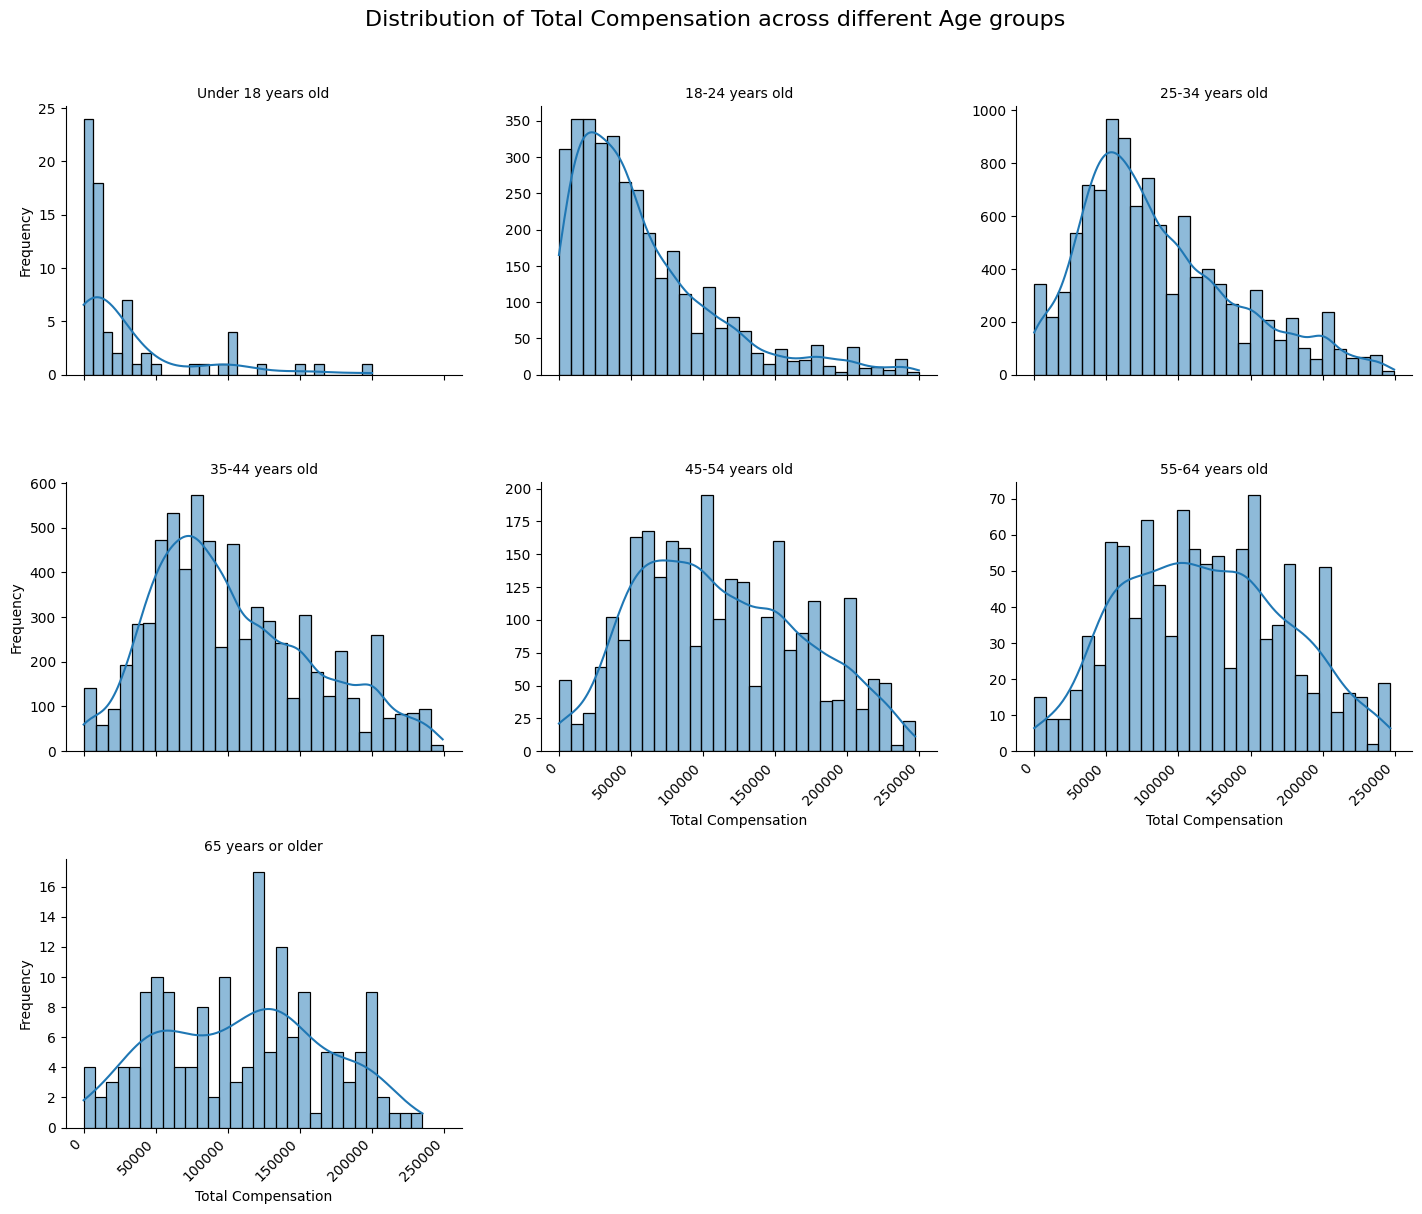

In [81]:
## Write your code here
%pip install seaborn
import seaborn as sns

query = "SELECT CompTotal, Age FROM main"
df = pd.read_sql_query(query, conn)

# Convert CompTotal to numeric (handling potential string errors)
df['CompTotal'] = pd.to_numeric(df['CompTotal'], errors='coerce')

# 3. Clean and Filter
# We drop NaNs and filter CompTotal to a readable range (e.g., < $250,000)
# to ensure the histograms actually show the distribution shape.
df_clean = df.dropna(subset=['CompTotal', 'Age'])
df_filtered = df_clean[df_clean['CompTotal'] < 250000]

# Define the logical order for Age groups
age_order = [
    'Under 18 years old',
    '18-24 years old',
    '25-34 years old',
    '35-44 years old',
    '45-54 years old',
    '55-64 years old',
    '65 years or older'
]

# Create Faceted Histograms
g = sns.FacetGrid(df_filtered, col="Age", col_wrap=3, height=4, aspect=1.2, 
                  col_order=age_order, sharey=False)

# Use element="step" or "bars" for the histogram
g.map(sns.histplot, "CompTotal", bins=30, kde=True)

# Formatting
g.set_axis_labels("Total Compensation", "Frequency")
g.set_titles("{col_name}")

# Rotate x-axis labels for each subplot
for ax in g.axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_horizontalalignment('right')

plt.subplots_adjust(top=0.9, hspace=0.4)
g.fig.suptitle('Distribution of Total Compensation across different Age groups', fontsize=16)

plt.show()

**2.2 Histogram of TimeSearching for Different Age Groups**


Objective: Use histograms to explore the distribution of `TimeSearching` (time spent searching for information) for respondents across different age groups.


In [70]:
## Write your code here

QUERY4 = """
SELECT TimeSearching, Age FROM main"""

df_Time = pd.read_sql_query(QUERY4, conn)

# Now re-run your check
print(df_Time)

      TimeSearching                 Age
0               NaN  Under 18 years old
1               NaN     35-44 years old
2               NaN     45-54 years old
3               NaN     18-24 years old
4               NaN     18-24 years old
...             ...                 ...
65432           NaN     18-24 years old
65433           NaN     25-34 years old
65434           NaN     25-34 years old
65435           NaN     18-24 years old
65436           NaN     18-24 years old

[65437 rows x 2 columns]


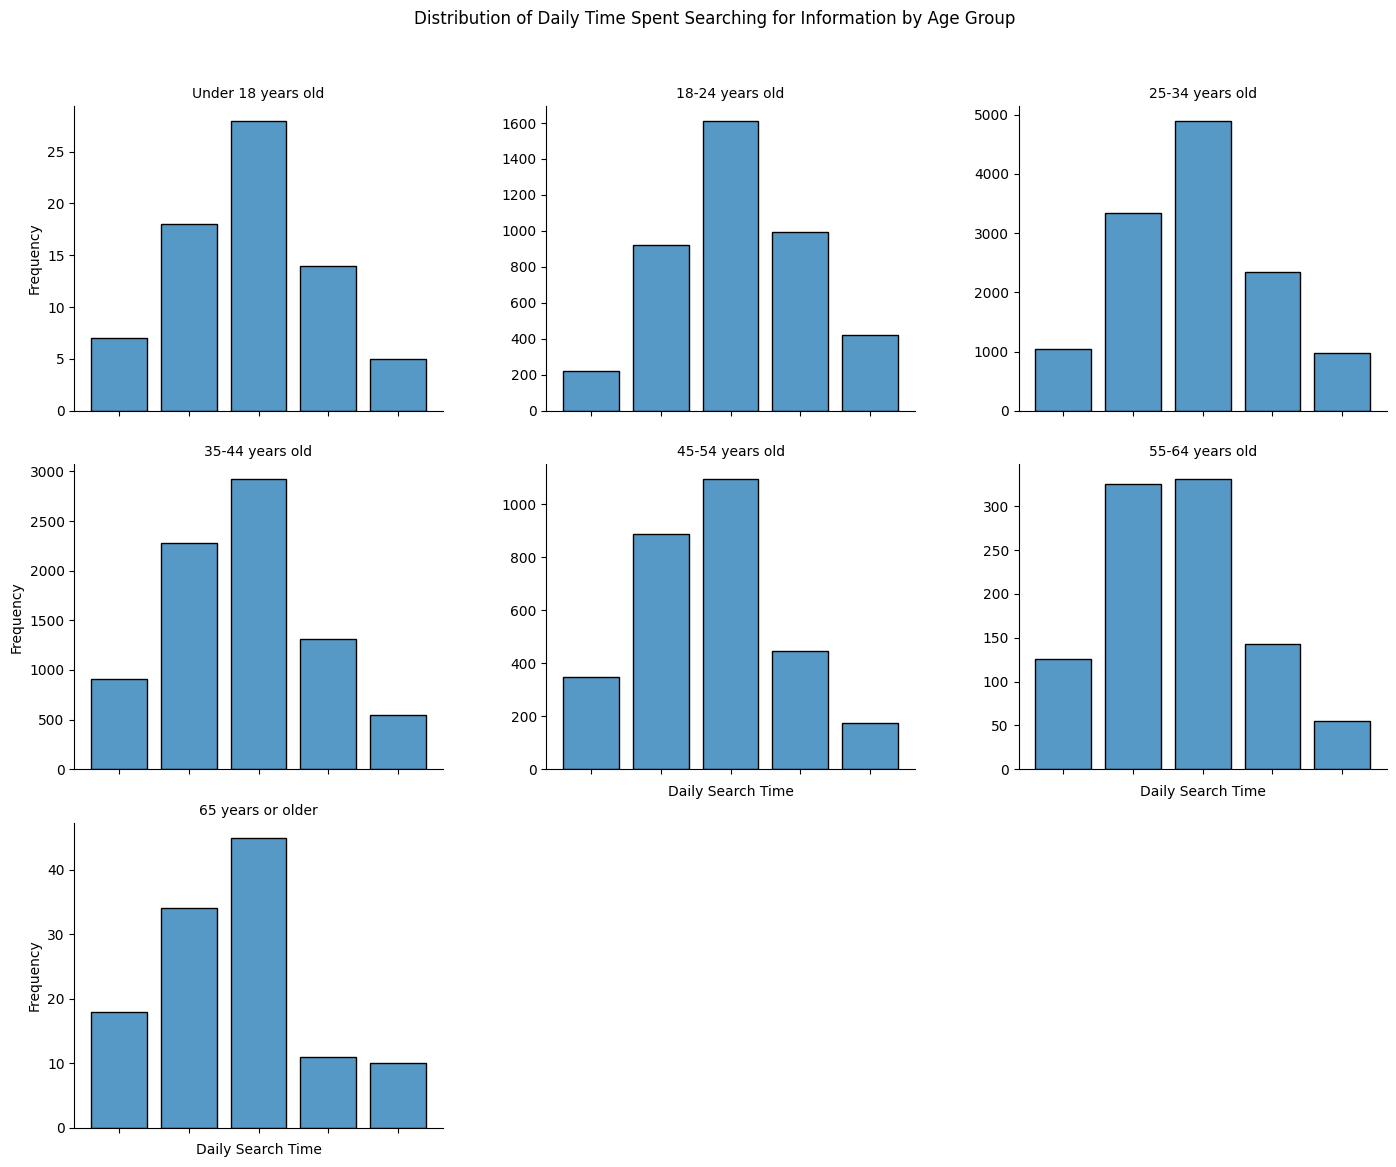

In [80]:

query = "SELECT TimeSearching, Age FROM main"
df = pd.read_sql_query(query, conn)

# This prevents the chart from sorting alphabetically
time_order = [
    'Less than 15 minutes a day',
    '15-30 minutes a day',
    '30-60 minutes a day',
    '60-120 minutes a day',
    'Over 120 minutes a day'
]

age_order = [
    'Under 18 years old',
    '18-24 years old',
    '25-34 years old',
    '35-44 years old',
    '45-54 years old',
    '55-64 years old',
    '65 years or older'
]

# Clean the data: Drop rows with missing values
df_clean = df.dropna(subset=['TimeSearching', 'Age'])

# Convert TimeSearching to a categorical type with your specific order
df_clean['TimeSearching'] = pd.Categorical(df_clean['TimeSearching'], 
                                           categories=time_order, 
                                           ordered=True)

# Create Faceted Histograms using Seaborn
# We use FacetGrid to create a separate plot for each age group
g = sns.FacetGrid(df_clean, col="Age", col_wrap=3, height=4, aspect=1.2, 
                  col_order=age_order, sharey=False)

# map the histplot to the grid
g.map(sns.histplot, "TimeSearching", shrink=0.8)

# Formatting and Titles
g.set_axis_labels("Daily Search Time", "Frequency")
g.set_titles("{col_name}")
g.set_xticklabels(rotation=45, horizontalalignment='right')

plt.subplots_adjust(top=0.9)
g.fig.suptitle('Distribution of Daily Time Spent Searching for Information by Age Group')

plt.show()

### 3. Visualizing the Composition of Data


**3.1 Histogram of Most Desired Databases (`DatabaseWantToWorkWith`)**


Objective: Visualize the most desired databases for future learning using a histogram of the top 5 databases.


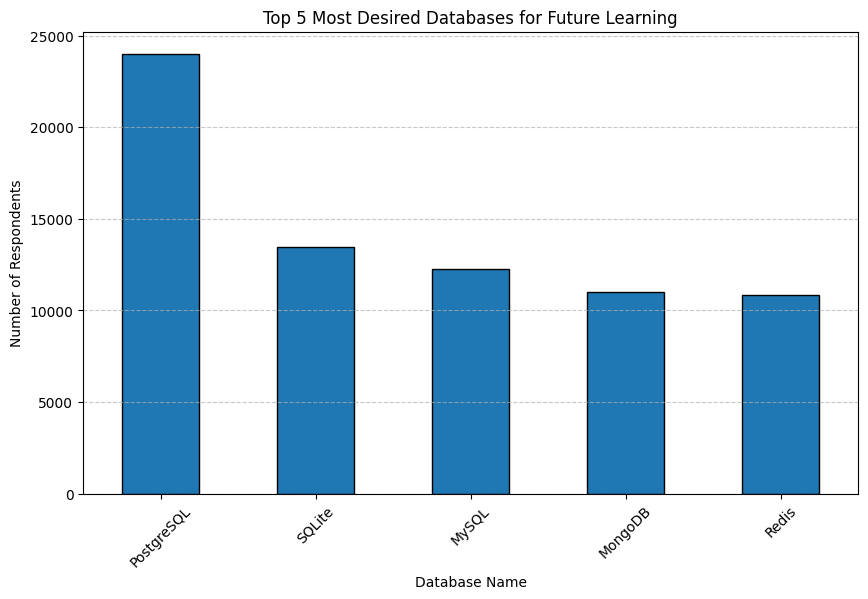

In [53]:
## Write your code here

query = "SELECT DatabaseWantToWorkWith FROM main"
df_db = pd.read_sql_query(query,conn)

df_db = df_db.dropna(subset=['DatabaseWantToWorkWith'])

# Split the semicolon-separated strings into a list and explode them into individual rows
# This turns "PostgreSQL;Redis" into two separate entries
db_list = df_db['DatabaseWantToWorkWith'].str.split(';').explode()

# 3. Count frequencies and get the Top 5
top_5_databases = db_list.value_counts().head(5)

# 4. Plot the "Histogram" (Frequency Bar Chart)
plt.figure(figsize=(10, 6))
top_5_databases.plot(kind='bar', edgecolor='black')

plt.title('Top 5 Most Desired Databases for Future Learning')
plt.xlabel('Database Name')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=45) # Rotate labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


**3.2 Histogram of Preferred Work Locations (`RemoteWork`)**


Objective: Use a histogram to explore the distribution of preferred work arrangements (`remote work`).


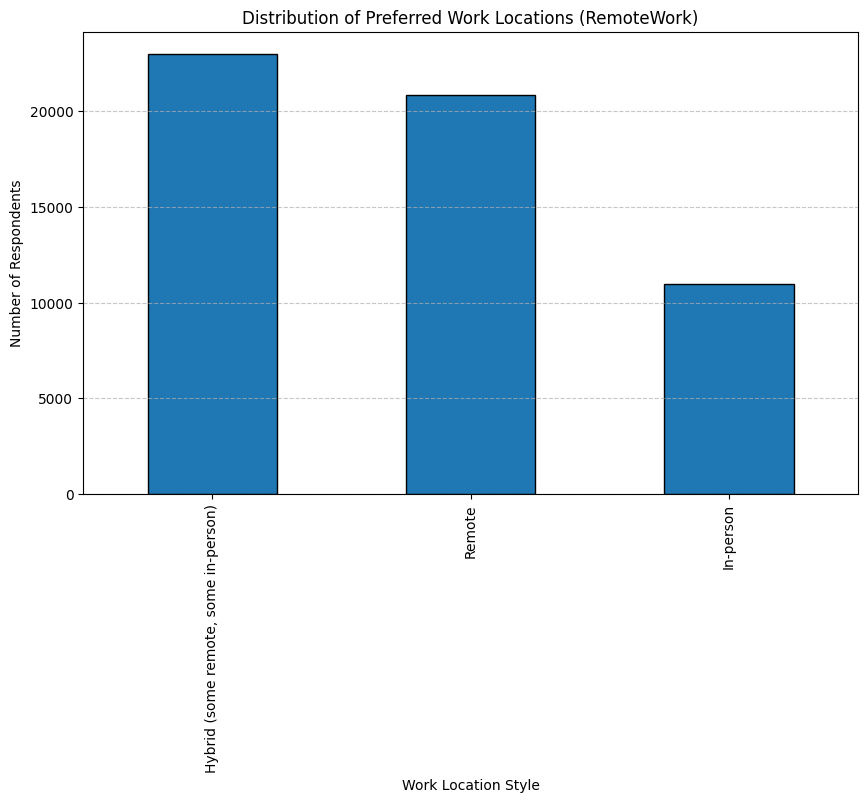

In [52]:
# Query RemoteWork from the 'main' table
query = "SELECT RemoteWork FROM main"
df_remote = pd.read_sql_query(query, conn)

# Clean the data (Drop missing responses)
df_remote = df_remote.dropna(subset=['RemoteWork'])

# Count the frequency of each work style
# This creates the data needed for the "histogram" distribution
remote_counts = df_remote['RemoteWork'].value_counts()

# Plot the distribution
plt.figure(figsize=(10, 6))
remote_counts.plot(kind='bar', edgecolor='black')

# Add labels and title
plt.title('Distribution of Preferred Work Locations (RemoteWork)')
plt.xlabel('Work Location Style')
plt.ylabel('Number of Respondents')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

### 4. Visualizing Comparison of Data


**4.1 Histogram of Median CompTotal for Ages 45 to 60**


Objective: Plot the histogram for `CompTotal` within the age group 45 to 60 to analyze compensation distribution among mid-career respondents.


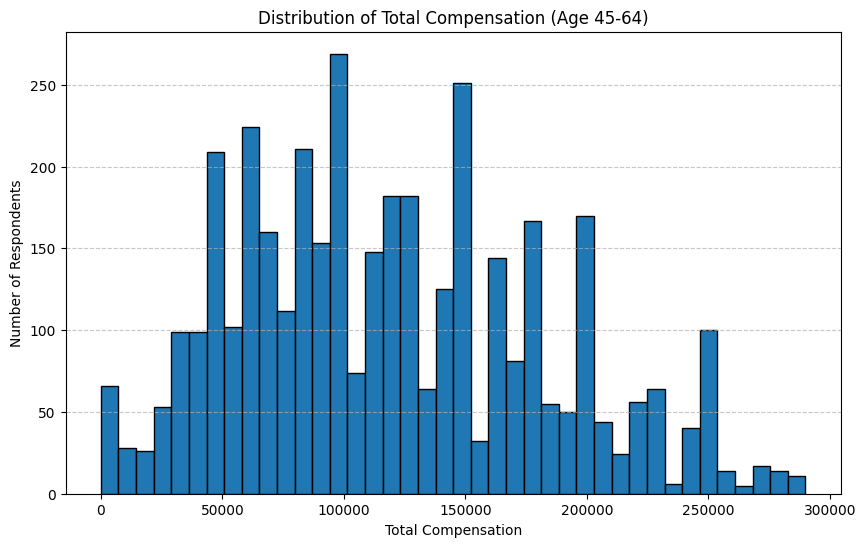

In [48]:
## Write your code here

query = "SELECT CompTotal, Age FROM main"
df_mid_career = pd.read_sql_query(query, conn)

# To cover the range 45-60, we include both the 45-54 and 55-64 categories
target_groups = ['45-54 years old', '55-64 years old']

# Filter the dataframe correctly (using df_mid_career instead of 'df')
df_mid_career = df_mid_career[df_mid_career['Age'].isin(target_groups)]

# Convert CompTotal to numeric
df_mid_career['CompTotal'] = pd.to_numeric(df_mid_career['CompTotal'], errors='coerce')

# Filter for visualization (Outliers > 300k make histograms hard to read)
# We use df_mid_career here consistently
df_plot = df_mid_career[df_mid_career['CompTotal'] < 300000].dropna(subset=['CompTotal'])

# Plot the Histogram
plt.figure(figsize=(10, 6))
plt.hist(df_plot['CompTotal'], bins=40, edgecolor='black')

plt.title('Distribution of Total Compensation (Age 45-64)')
plt.xlabel('Total Compensation')
plt.ylabel('Number of Respondents')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

**4.2 Histogram of Job Satisfaction (`JobSat`) by YearsCodePro**


Objective: Plot the histogram for `JobSat` scores based on respondents' years of professional coding experience.


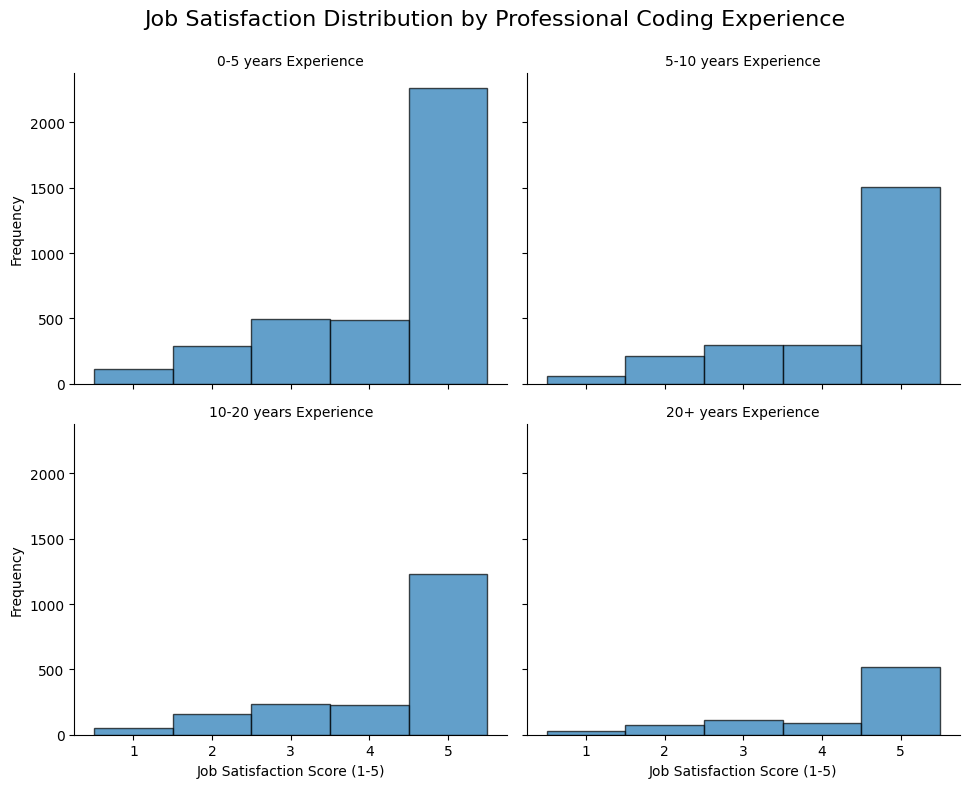

In [36]:

# Query JobSat and YearsCodePro
query = "SELECT JobSat, YearsCodePro FROM main"
df = pd.read_sql_query(query, conn)

# Clean YearsCodePro (Handle strings and convert to numeric)
df['YearsCodePro'] = df['YearsCodePro'].replace({
    'Less than 1 year': 0.5, 
    'More than 50 years': 51
})
df['YearsCodePro'] = pd.to_numeric(df['YearsCodePro'], errors='coerce')

# Create Experience Groups for comparison
bins = [0, 5, 10, 20, 100]
labels = ['0-5 years', '5-10 years', '10-20 years', '20+ years']
df['ExpGroup'] = pd.cut(df['YearsCodePro'], bins=bins, labels=labels)

# Drop NaNs to ensure the plot works
df_clean = df.dropna(subset=['JobSat', 'ExpGroup'])

# Plot Faceted Histograms
g = sns.FacetGrid(df_clean, col="ExpGroup", col_wrap=2, height=4, aspect=1.2)
g.map(plt.hist, "JobSat", bins=[1, 2, 3, 4, 5, 6], align='left', 
       edgecolor='black', alpha=0.7)

# Formatting the plots
g.set_axis_labels("Job Satisfaction Score (1-5)", "Frequency")
g.set_titles("{col_name} Experience")
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Job Satisfaction Distribution by Professional Coding Experience', fontsize=16)

plt.show()

### Final step: Close the database connection


Once you've completed the lab, make sure to close the connection to the SQLite database:



In [ ]:
conn.close()

### Summary


In this lab, you used histograms to visualize various aspects of the dataset, focusing on:

- Distribution of compensation, coding experience, and work hours.

- Relationships in compensation across age groups and work status.

- Composition of data by desired databases and work environments.

- Comparisons of job satisfaction across years of experience.

Histograms helped reveal patterns and distributions in the data, enhancing your understanding of developer demographics and preferences.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
